# Exercise 0: Python and Machine Learning Warm-Up
---
## Table of Contents
1. [Introduction](#introduction)
2. [Python Fundamentals](#python-fundamentals)
3. [NumPy: Arrays and Vectorisation](#numpy-arrays-and-vectorisation)
4. [Plotting with Matplotlib](#plotting-with-matplotlib)
5. [A First Model: the Perceptron](#a-first-model-the-perceptron)
6. [Learning from Data: Gradient Descent](#learning-from-data-gradient-descent)
7. [When One Line Is Not Enough](#when-one-line-is-not-enough)
8. [Bridge to PyTorch](#bridge-to-pytorch)

## Introduction
Welcome to Exercise 0! This exercise is a warm-up: it exists to get you comfortable with the tools before you meet the real machine learning problems in Exercises 1, 2 and 3.

There is no dataset to download here and nothing to configure. Everything you need is generated on the spot.

By the end of this notebook you will have:

- refreshed the Python you will use throughout the course — lists, dictionaries, loops, and functions;
- learned to work with **NumPy** arrays, and seen why we avoid writing loops over data;
- plotted a function and a training curve with **Matplotlib**;
- built a **perceptron**, the simplest neural network there is, by hand;
- trained it with **gradient descent**, writing the weight update yourself;
- seen what **PyTorch** does for you, which is exactly where Exercise 1 picks up.

Cells marked <strong style="color:red;">TODO</strong> are for you to complete. Everything else you can simply run. Solutions are at the bottom of the notebook — try each exercise yourself before looking.

## Python Fundamentals
---
Let us start from the beginning. A **variable** is a name bound to a value, and Python figures out the type for you.

The `f'...'` string syntax below is called an **f-string**: any expression inside `{}` is evaluated and inserted into the text. You will see it used for printing losses during training.

In [1]:
n_epochs = 10          # int
learning_rate = 0.01   # float
model_name = "perceptron"   # str
is_training = True     # bool

print(f'We will train the {model_name} for {n_epochs} epochs at a learning rate of {learning_rate}.')
print(f'Types: {type(n_epochs)}, {type(learning_rate)}, {type(model_name)}, {type(is_training)}')

# Numbers formatted to a fixed number of decimals - useful for printing losses:
loss = 0.0123456789
print(f'Loss: {loss:.4f}')

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")



We will train the perceptron for 10 epochs at a learning rate of 0.01.
Types: <class 'int'>, <class 'float'>, <class 'str'>, <class 'bool'>
Loss: 0.0123
Using device: cuda


### Lists, dictionaries and loops
A **list** is an ordered, changeable collection. A **dictionary** maps keys to values, and is how you will most often carry configuration and results around.

Note that Python indexing starts at `0`, and that `-1` means "the last element".

In [4]:
# Lists
losses = [0.9, 0.7, 0.55, 0.4, 0.31]

print(f'The whole list:      {losses}')
print(f'First element:       {losses[0]}')
print(f'Last element:        {losses[-1]}')
print(f'First three:         {losses[:3]}')
print(f'Number of elements:  {len(losses)}')

losses.append(0.25)          # add one element to the end
print(f'After appending:     {losses}')

# Dictionaries
config = {'epochs': 10, 'learning_rate': 0.01, 'hidden_dim': 120}

print(f"\nLearning rate from the config: {config['learning_rate']}")
config['batch_size'] = 32    # add a new key
print(f'All configuration keys: {list(config.keys())}')

# Looping over a list, with the index available via enumerate:
print('\nLoss per epoch:')
for epoch, loss in enumerate(losses):
    print(f'  epoch {epoch}: loss = {loss:.2f}')



The whole list:      [0.9, 0.7, 0.55, 0.4, 0.31]
First element:       0.9
Last element:        0.31
First three:         [0.9, 0.7, 0.55]
Number of elements:  5
After appending:     [0.9, 0.7, 0.55, 0.4, 0.31, 0.25]

Learning rate from the config: 0.01
All configuration keys: ['epochs', 'learning_rate', 'hidden_dim', 'batch_size']

Loss per epoch:
  epoch 0: loss = 0.90
  epoch 1: loss = 0.70
  epoch 2: loss = 0.55
  epoch 3: loss = 0.40
  epoch 4: loss = 0.31
  epoch 5: loss = 0.25


### Functions and list comprehensions
A **function** groups code you want to reuse. A **list comprehension** builds a list in one line, and is the idiomatic way to transform a collection in Python.

<strong style="color:red;"> 0.1: TODO: Write a function and a list comprehension</strong>

1. Complete `mean()` so that it returns the average of a list of numbers.
2. Use a list comprehension to build `squared`, containing the square of every number in `values`.

*Hint:* `sum(numbers)` adds up a list, and `len(numbers)` gives its length. A list comprehension reads `[expression for item in collection]`.

In [5]:
values = [1, 2, 3, 4, 5]

print(2**2)
def mean(numbers):
    """Return the arithmetic mean of a list of numbers."""
    # -------------------------------------------
    #  TODO: Compute and return the mean
    mean = sum(numbers) / len(numbers)
    # -------------------------------------------
    return mean
    # -------------------------------------------
    # END
    # -------------------------------------------


# -------------------------------------------
#  TODO: Build a list of the squares of `values`
# -------------------------------------------
squared = [value**2 for value in values]
# -------------------------------------------
# END
# -------------------------------------------

print(f'mean(values) = {mean(values)}      (expected: 3.0)')
print(f'squared      = {squared}   (expected: [1, 4, 9, 16, 25])')


4
mean(values) = 3.0      (expected: 3.0)
squared      = [1, 4, 9, 16, 25]   (expected: [1, 4, 9, 16, 25])


## NumPy: Arrays and Vectorisation
---
Machine learning is arithmetic on large blocks of numbers. Python lists are too slow for that, so we use **NumPy** arrays instead. Nearly everything you do in this course — and every PyTorch tensor you will meet in Exercise 1 — behaves like a NumPy array.

The single most important property of an array is its **shape**, which tells you how many elements it holds along each dimension. A large share of the errors you will hit this course are shape errors, so it is worth getting comfortable reading them now.

In [6]:
import numpy as np

# From a Python list:
a = np.array([1.0, 2.0, 3.0, 4.0])

# Useful constructors:
zeros = np.zeros(5)              # five zeros
ones = np.ones((2, 3))           # a 2x3 block of ones
grid = np.linspace(0, 1, 5)      # five evenly spaced values from 0 to 1
rand = np.random.default_rng(0).uniform(-1, 1, (2, 3))   # random, reproducible via the seed

print(f'a       = {a},  shape {a.shape}, dtype {a.dtype}')
print(f'zeros   = {zeros},  shape {zeros.shape}')
print(f'grid    = {grid}')
print(f'\nones (shape {ones.shape}):\n{ones}')
print(f'\nrand (shape {rand.shape}):\n{rand}')

a       = [1. 2. 3. 4.],  shape (4,), dtype float64
zeros   = [0. 0. 0. 0. 0.],  shape (5,)
grid    = [0.   0.25 0.5  0.75 1.  ]

ones (shape (2, 3)):
[[1. 1. 1.]
 [1. 1. 1.]]

rand (shape (2, 3)):
[[ 0.27392337 -0.46042657 -0.91805295]
 [-0.96694473  0.62654048  0.82551115]]


### Indexing, slicing and masks
Indexing works like it does for lists, but extends to several dimensions. A **boolean mask** selects every element for which a condition holds — this is how the plotting helpers in this course separate one class from another.

In [13]:
x = np.array([10, 20, 30, 40, 50, 60])

print(f'x[0]      = {x[0]}          (first element)')
print(f'x[-1]     = {x[-1]}          (last element)')
print(f'x[1:4]    = {x[1:4]}   (elements 1, 2, 3 - the end is excluded)')

# A boolean mask:
mask = x > 30
print(f'\nmask      = {mask}')
print(f'x[mask]   = {x[mask]}    (only the elements where the mask is True)')

# Two dimensions: the first index is the row, the second the column.
M = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f'\nM has shape {M.shape}')
print(f'M[0, 2]   = {M[0, 2]}   (row 0, column 2)')
print(f'M[:, 1]   = {M[:, 1]}  (every row, column 1)')

x[0]      = 10          (first element)
x[-1]     = 60          (last element)
x[1:4]    = [20 30 40]   (elements 1, 2, 3 - the end is excluded)

mask      = [False False False  True  True  True]
x[mask]   = [40 50 60]    (only the elements where the mask is True)

M has shape (2, 3)
M[0, 2]   = 3   (row 0, column 2)
M[:, 1]   = [2 5]  (every row, column 1)


### Vectorisation
NumPy applies operations to whole arrays at once. This is called **vectorisation**, and it is both shorter to write and dramatically faster than looping, because the loop runs in optimised C code instead of in Python.

Run the cell below to see the difference on a million numbers.

In [14]:
import time

big = np.random.default_rng(0).uniform(0, 1, 1_000_000)

# The slow way: a Python loop.
start = time.time()
result_loop = []
for value in big:
    result_loop.append(value * 2 + 1)
loop_time = time.time() - start

# The fast way: one vectorised expression.
start = time.time()
result_vectorised = big * 2 + 1
vectorised_time = time.time() - start

print(f'Python loop: {loop_time:.4f} s')
print(f'Vectorised:  {vectorised_time:.4f} s')
print(f'Speed-up:    {loop_time / vectorised_time:.0f}x')
print(f'Same answer? {np.allclose(result_loop, result_vectorised)}')

Python loop: 0.1750 s
Vectorised:  0.0060 s
Speed-up:    29x
Same answer? True


<strong style="color:red;"> 0.2: TODO: Vectorise a computation</strong>

Below, `squared_error_loop` computes the mean squared error between predictions and targets using a Python loop. Replace the loop with a single vectorised NumPy expression.

*Hint:* arithmetic between two arrays of the same shape acts element by element, and `np.mean(...)` averages an array.

In [15]:
example_predictions = np.array([0.9, 0.2, 0.7, 0.4, 0.55])
example_targets = np.array([1.0, 0.0, 1.0, 0.0, 1.0])

# The loop version, for reference:
total = 0.0
for i in range(len(example_predictions)):
    total += (example_predictions[i] - example_targets[i]) ** 2
squared_error_loop = total / len(example_predictions)

# -------------------------------------------
#  TODO: Compute the same value without a loop
MSEMatrix = (example_predictions - example_targets) ** 2 
# -------------------------------------------
squared_error_vectorised = np.mean(MSEMatrix)
# -------------------------------------------
# END
# -------------------------------------------

print(f'Loop:       {squared_error_loop:.6f}')
print(f'Vectorised: {squared_error_vectorised}')

Loop:       0.100500
Vectorised: 0.10049999999999999


## Plotting with Matplotlib
---
You will plot constantly in this course: to inspect data before training, and to watch a loss curve during it.

The function below is the **sigmoid**, written $\sigma(a)$:

$\sigma(a) = \frac{1}{1 + e^{-a}}$

It squashes any number into the range $(0, 1)$, which lets us read its output as a class probability. We will use it as the perceptron's activation function in a moment. Its derivative has a particularly convenient form that we will need when we train:

$\sigma'(a) = \sigma(a)\,(1 - \sigma(a))$

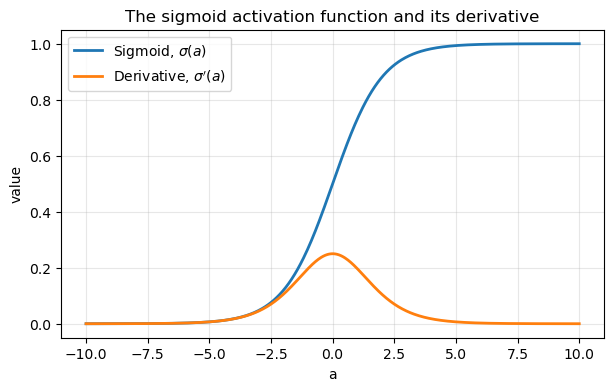

In [7]:
import matplotlib.pyplot as plt


def sigmoid(a):
    """The logistic sigmoid, applied element-wise."""
    return 1 / (1 + np.exp(-a))


a = np.linspace(-10, 10, 500)

plt.figure(figsize=(7, 4))
plt.plot(a, sigmoid(a), label=r'Sigmoid, $\sigma(a)$', linewidth=2)
plt.plot(a, sigmoid(a) * (1 - sigmoid(a)), label=r"Derivative, $\sigma'(a)$", linewidth=2)
plt.xlabel('a')
plt.ylabel('value')
plt.title('The sigmoid activation function and its derivative')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## A First Model: the Perceptron
---
We now have everything we need to build a model.

The **perceptron** is the simplest neural network: it takes some inputs, multiplies each by a **weight**, adds them up together with a **bias**, and passes the result through an activation function. For two inputs:

$a = w_1 x_1 + w_2 x_2 + b$

$o = \sigma(a)$

That is the whole model. Every network you build later in this course — the controller in Exercise 1, the CNN in Exercise 2 — is this same operation, repeated and stacked.

Let us look at the problem we will ask it to solve. Each point has two features, `x1` and `x2`, and belongs to class `0` or `1`.

In [ ]:
from additional.data import get_simple_data
from additional.plots import plot_data

x1, x2, t = get_simple_data(n_samples=300)

print(f'x1 has shape {x1.shape}, x2 has shape {x2.shape}, t has shape {t.shape}')
print(f'The first five targets are {t[:5]}')

plot_data(x1, x2, t, title='A linearly separable problem')

: 

The two classes are separated by a straight line, so a single perceptron can solve this. Its **decision boundary** is the line where $a = 0$, that is, where the model switches from predicting one class to the other.

<strong style="color:red;"> 0.3: TODO: Implement the perceptron's forward pass</strong>

Complete `perceptron_output()` so that it computes $\sigma(w_1 x_1 + w_2 x_2 + b)$.

Write it **vectorised**: `x1` and `x2` are arrays holding every sample, so your function should return an array of outputs, one per sample, without looping.

In [19]:
def perceptron_output(x1, x2, w1, w2, bias):
    """Return the perceptron's output for every sample in x1, x2."""
    # -------------------------------------------
    #  TODO: Compute the weighted sum, then apply the sigmoid
    a = x1 * w1 + x2 * w2 + bias
    o = sigmoid(a)
    # -------------------------------------------
    return o
    # -------------------------------------------
    # END
    # -------------------------------------------


# We happen to know the weights that generated this data, so we can use them
# to check your implementation: with these, the accuracy should be 100%.
output = perceptron_output(x1, x2, w1=-2.0, w2=-2.0, bias=0.0)

if output is None:
    raise ValueError('perceptron_output is not implemented yet.')

print(f'Output shape: {output.shape}   (expected: {x1.shape})')
print(f'First five outputs: {np.round(output[:5], 3)}')

# Turn the outputs into hard class predictions and measure the accuracy:
predictions = (output > 0.5).astype(int)
print(f'Accuracy with the true weights: {np.mean(predictions == t):.1%}')

Output shape: (300,)   (expected: (300,))
First five outputs: [0.    0.997 1.    1.    0.   ]
Accuracy with the true weights: 100.0%


## Learning from Data: Gradient Descent
---
Above we cheated: we already knew the weights that generated the data. On a real problem nobody hands you the answer, and with thousands of weights you could not guess them anyway. So we let the model **learn** them from the data instead.

First we need a **loss function** that measures how wrong the model is. We use the squared error, averaged over all samples:

$\mathcal{L} = (o - t)^2$

Then we ask: if I nudge a weight up, does the loss go up or down? That is exactly what the **gradient** $\frac{\partial \mathcal{L}}{\partial w_i}$ tells us. Applying the chain rule through $o = \sigma(a)$ and $a = \sum_i w_i x_i + b$:

$\frac{\partial \mathcal{L}}{\partial w_i} = \underbrace{2(o - t)}_{\text{from the loss}} \cdot \underbrace{\sigma'(a)}_{\text{from the activation}} \cdot \underbrace{x_i}_{\text{from the weighted sum}}$

If the gradient is positive, increasing the weight increases the loss, so we should decrease the weight — and vice versa. So we always step **against** the gradient:

$w_i \leftarrow w_i - \alpha \frac{\partial \mathcal{L}}{\partial w_i}$

The step size $\alpha$ is the **learning rate**. Too small and training crawls; too large and it overshoots and never settles. You will tune it in every exercise in this course.

<strong style="color:red;"> 0.4: TODO: Implement one step of gradient descent</strong>

Complete the training loop below:

1. Compute the model output for the whole dataset using your `perceptron_output` from 0.3.
2. Compute the mean squared error and store it in `loss`.
3. Compute the gradient with respect to `w1`, `w2` and `bias`, and update all three.

*Hint:* `sigmoid_derivative = output * (1 - output)`, since $\sigma'(a) = \sigma(a)(1 - \sigma(a))$ and `output` is already $\sigma(a)$. For the bias, note that $\frac{\partial a}{\partial b} = 1$. Use `np.mean(...)` to average each gradient over the samples.

In [ ]:
# Starting parameters - deliberately a poor guess, so there is something to learn:
w1 = 0.0
w2 = 3.0
bias = 0.0

# Training configuration:
n_epochs = 200
learning_rate = 0.5

losses = []

for epoch in range(n_epochs):
    # -------------------------------------------
    #  TODO: Forward pass, loss, gradients, and weight update
    # -------------------------------------------
    output = perceptron_output(x1, x2, w1, w2, bias)
    loss = np.mean((output - t)**2)
    dadb = 1
    gradcalc = 2 * (output - t) * output * (1 - output)
    grad1 = np.mean(gradcalc * x1)
    grad2 = np.mean(gradcalc * x2)
    gradb = np.mean(gradcalc * dadb)

    w1 = w1 - learning_rate * grad1
    w2 = w2 - learning_rate * grad2
    bias = bias - learning_rate * gradb

    # -------------------------------------------
    # END
    # -------------------------------------------

    losses.append(loss)

    if epoch % 20 == 0:
        print(f'Epoch {epoch:>3}: loss = {loss:.4f}')

print(f'\nFinal parameters: w1 = {w1:.3f}, w2 = {w2:.3f}, bias = {bias:.3f}')

: 

Run the cell below to see the result: the loss should fall steadily, and the decision boundary should end up separating the two classes.

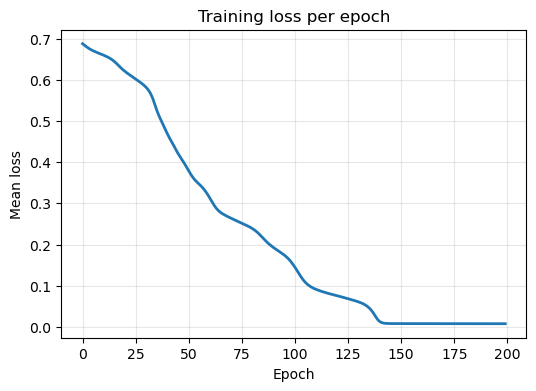

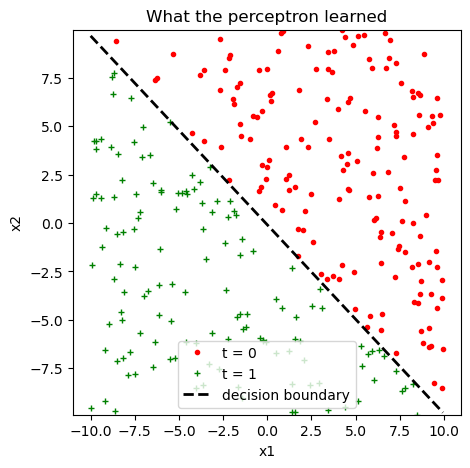

Final accuracy: 100.0%


In [23]:
from additional.plots import plot_loss_curve, plot_decision_boundary

plot_loss_curve(losses, title='Training loss per epoch')
plot_decision_boundary(x1, x2, t, w1, w2, bias, title='What the perceptron learned')

final_predictions = (perceptron_output(x1, x2, w1, w2, bias) > 0.5).astype(int)
print(f'Final accuracy: {np.mean(final_predictions == t):.1%}')

## When One Line Is Not Enough
---
A single perceptron can only ever draw a **straight line**. That is its fundamental limitation, and it is the reason deep networks exist.

The dataset below is XOR-like: class `1` occupies two opposite corners. No straight line separates it. Run the cell and watch the training fail — the loss barely moves, and the accuracy lands far short of the 100% we reached on the separable problem. The best a straight line can do here is clip one corner.

This is not a bug in your code. It is the model being too simple for the problem. The fix is to stack layers, which is exactly what you will do in Exercise 1.

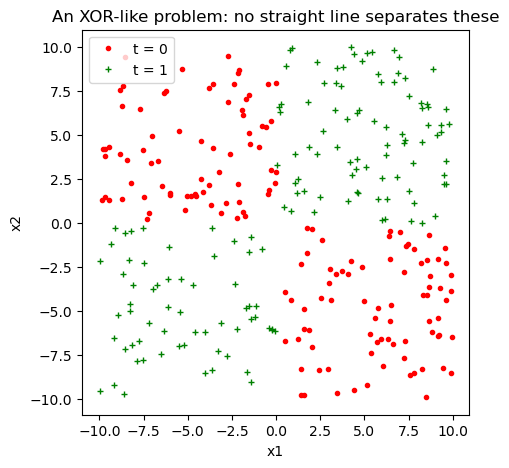

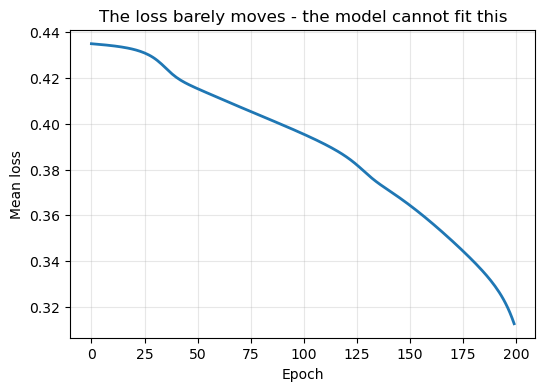

Accuracy on the difficult problem: 64.3%
Compare that with the 100% the same model reached on the separable problem.


In [24]:
from additional.data import get_difficult_data

x1_hard, x2_hard, t_hard = get_difficult_data(n_samples=300)
plot_data(x1_hard, x2_hard, t_hard, title='An XOR-like problem: no straight line separates these')

# Train exactly as before, on the harder data:
w1_hard, w2_hard, bias_hard = 0.0, 3.0, 0.0
hard_losses = []

for epoch in range(200):
    output = perceptron_output(x1_hard, x2_hard, w1_hard, w2_hard, bias_hard)
    hard_losses.append(np.mean((output - t_hard) ** 2))

    common = 2 * (output - t_hard) * output * (1 - output)
    w1_hard -= 0.5 * np.mean(common * x1_hard)
    w2_hard -= 0.5 * np.mean(common * x2_hard)
    bias_hard -= 0.5 * np.mean(common)

plot_loss_curve(hard_losses, title='The loss barely moves - the model cannot fit this')

hard_predictions = (perceptron_output(x1_hard, x2_hard, w1_hard, w2_hard, bias_hard) > 0.5).astype(int)
print(f'Accuracy on the difficult problem: {np.mean(hard_predictions == t_hard):.1%}')
print('Compare that with the 100% the same model reached on the separable problem.')

## Bridge to PyTorch
---
You have now written, by hand, every piece of a training loop: a forward pass, a loss, a set of gradients, and a weight update.

**PyTorch does the gradients for you.** You describe the forward pass; it records the operations and works out $\frac{\partial \mathcal{L}}{\partial w}$ automatically. That is the single biggest thing it buys you, and it is why nobody differentiates by hand once the model is larger than a perceptron.

The cell below trains the same perceptron on the same data in PyTorch. Compare it line by line with what you wrote above:

| You wrote by hand | PyTorch equivalent |
| --- | --- |
| `sigmoid(w1*x1 + w2*x2 + b)` | `model(x)` |
| `np.mean((output - t)**2)` | `criterion(output, t)` |
| the gradient formulas | `loss.backward()` |
| `w1 -= learning_rate * grad` | `optimizer.step()` |

Every one of those right-hand entries appears in Exercise 1.

In [25]:
import torch
from torch import nn

# NumPy arrays become tensors. PyTorch expects the inputs stacked into
# one array of shape (n_samples, n_features):
x = torch.tensor(np.stack([x1, x2], axis=1), dtype=torch.float32)
y = torch.tensor(t, dtype=torch.float32).unsqueeze(1)

print(f'x has shape {x.shape}  (300 samples, 2 features each)')
print(f'y has shape {y.shape}\n')

# The model: one linear layer (our weighted sum plus bias) and a sigmoid.
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid(),
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

for epoch in range(200):
    output = model(x)               # forward pass
    loss = criterion(output, y)     # loss

    optimizer.zero_grad()           # clear gradients from the previous step
    loss.backward()                 # PyTorch computes every gradient for you
    optimizer.step()                # and the optimizer applies the update

    if epoch % 40 == 0:
        print(f'Epoch {epoch:>3}: loss = {loss.item():.4f}')

accuracy = ((model(x) > 0.5).float() == y).float().mean()
print(f'\nFinal accuracy: {accuracy:.1%}')

x has shape torch.Size([300, 2])  (300 samples, 2 features each)
y has shape torch.Size([300, 1])

Epoch   0: loss = 0.1641
Epoch  40: loss = 0.0202
Epoch  80: loss = 0.0159
Epoch 120: loss = 0.0137
Epoch 160: loss = 0.0124

Final accuracy: 100.0%


---
You have reached the end of Exercise 0, good job!

You now have the Python, the NumPy and the mental model of a training loop that Exercises 1 to 3 assume. In Exercise 1 you will use exactly this pipeline — data, model, loss, optimizer, loop — on a real problem: flying a quadrotor.

If any section here felt shaky, come back to it. It is much cheaper to sort out a shape error now than in the middle of training a network.

# Solutions:

In [ ]:
# 0.1 VANILLA SOLUTION:
values = [1, 2, 3, 4, 5]


def mean(numbers):
    """Return the arithmetic mean of a list of numbers."""
    # -------------------------------------------
    #  TODO: Compute and return the mean
    # -------------------------------------------
    return sum(numbers) / len(numbers)
    # -------------------------------------------
    # END
    # -------------------------------------------


# -------------------------------------------
#  TODO: Build a list of the squares of `values`
# -------------------------------------------
squared = [v ** 2 for v in values]
# -------------------------------------------
# END
# -------------------------------------------

print(f'mean(values) = {mean(values)}      (expected: 3.0)')
print(f'squared      = {squared}   (expected: [1, 4, 9, 16, 25])')

In [ ]:
# 0.2 VANILLA SOLUTION:
example_predictions = np.array([0.9, 0.2, 0.7, 0.4, 0.55])
example_targets = np.array([1.0, 0.0, 1.0, 0.0, 1.0])

# -------------------------------------------
#  TODO: Compute the same value without a loop
# -------------------------------------------
squared_error_vectorised = np.mean((example_predictions - example_targets) ** 2)
# -------------------------------------------
# END
# -------------------------------------------

print(f'Vectorised: {squared_error_vectorised:.6f}   (expected: 0.100500)')

In [ ]:
# 0.3 VANILLA SOLUTION:
def perceptron_output(x1, x2, w1, w2, bias):
    """Return the perceptron's output for every sample in x1, x2."""
    # -------------------------------------------
    #  TODO: Compute the weighted sum, then apply the sigmoid
    # -------------------------------------------
    a = w1 * x1 + w2 * x2 + bias
    return sigmoid(a)
    # -------------------------------------------
    # END
    # -------------------------------------------


output = perceptron_output(x1, x2, w1=-2.0, w2=-2.0, bias=0.0)
predictions = (output > 0.5).astype(int)
print(f'Accuracy with the true weights: {np.mean(predictions == t):.1%}')

In [ ]:
# 0.4 VANILLA SOLUTION:
w1 = 0.0
w2 = 3.0
bias = 0.0

n_epochs = 200
learning_rate = 0.5

losses = []

for epoch in range(n_epochs):
    # -------------------------------------------
    #  TODO: Forward pass, loss, gradients, and weight update
    # -------------------------------------------
    output = perceptron_output(x1, x2, w1, w2, bias)
    loss = np.mean((output - t) ** 2)

    # dL/da = dL/do * do/da, shared by all three parameters:
    common = 2 * (output - t) * output * (1 - output)

    grad_w1 = np.mean(common * x1)
    grad_w2 = np.mean(common * x2)
    grad_bias = np.mean(common)

    w1 -= learning_rate * grad_w1
    w2 -= learning_rate * grad_w2
    bias -= learning_rate * grad_bias
    # -------------------------------------------
    # END
    # -------------------------------------------

    losses.append(loss)

    if epoch % 20 == 0:
        print(f'Epoch {epoch:>3}: loss = {loss:.4f}')

print(f'\nFinal parameters: w1 = {w1:.3f}, w2 = {w2:.3f}, bias = {bias:.3f}')